In [1]:
!pip install diffrax equinox optax lineax --quiet
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jrandom
import optax
import matplotlib.pyplot as plt
import diffrax
import lineax as lx
from tqdm.notebook import tqdm
import random
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.2/193.2 kB 5.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.4/97.4 kB 5.7 MB/s eta 0:00:00


## Dataset

The dataset consists of synthetic 2D spiral trajectories.

- Total samples: **10,000**
- Each sample is a trajectory of **100 time steps**
- Each time step contains a 2D point $(x, y)$
- An additional scalar label $\alpha$ is associated with each trajectory

**Shapes**
- `xy_train`: $(10000, 100, 2)$
- `xy_test`: $(10000, 100, 2)$
- `alpha_train`: $(10000, 1)$

**Preprocessing**
- 75% / 25% train–test split  
- Standard scaling applied using training statistics only  
- Time normalized to a shared grid $t \in [0, 1]$ with 100 points  

This normalization is essential for numerical stability when training ODE and SDE models.


['xy_train', 'alpha_train', 'xy_test']
(10000, 100, 2) (10000, 1)
(10000, 100, 2)


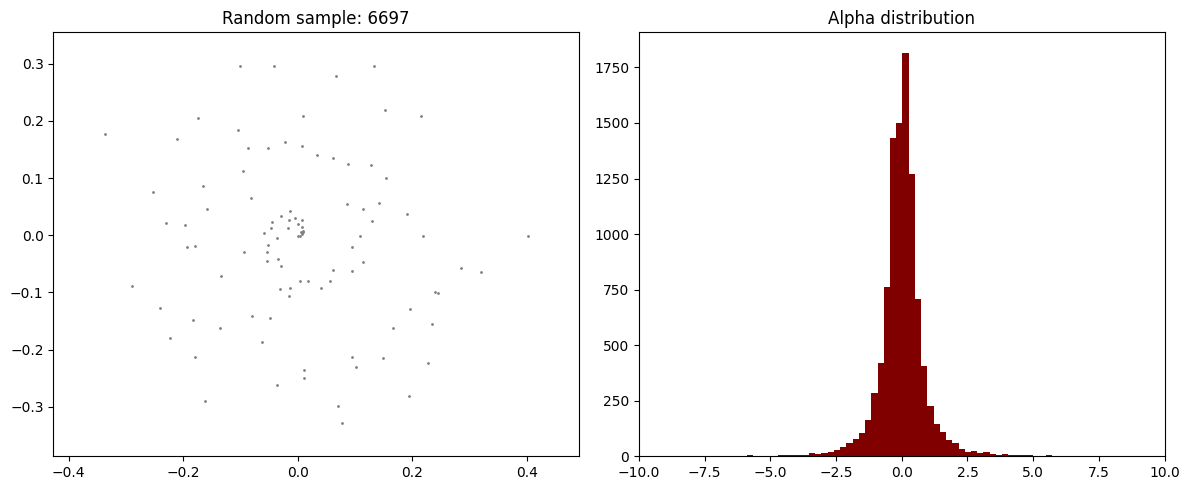

In [2]:
covid_data = jnp.load("/kaggle/input/spirals/spirals (1).npz")

print(covid_data.files)

xy_train = covid_data["xy_train"] # (10000, 100, 2)
xy_test = covid_data["xy_test"] # (10000, 100, 2)
alpha_train = covid_data["alpha_train"] # (10000, 1)

alpha_mean = jnp.mean(alpha_train)
alpha_std = jnp.std(alpha_train)
alpha_normalized = (alpha_train - alpha_mean) / alpha_std

xy_mean = jnp.mean(xy_train, axis=(0, 1), keepdims=True)
xy_std = jnp.std(xy_train, axis=(0, 1), keepdims=True)
xy_normalized = (xy_train - xy_mean) / xy_std

print(xy_train.shape, alpha_train.shape)
print(xy_test.shape)

rand_idx = random.randint(0, xy_train.shape[0] - 1)
x_train = xy_normalized[rand_idx, :, 0]
y_train = xy_normalized[rand_idx, :, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# scatter of a random training sample
axes[0].scatter(x_train.flatten(), y_train.flatten(), s=1, color='gray')
axes[0].set_title(f"Random sample: {rand_idx}")
axes[0].axis("equal")

# alpha distribution
axes[1].hist(alpha_normalized.flatten(), bins=100, color='maroon')
axes[1].set_xlim(-10, 10)
axes[1].set_title("Alpha distribution")

plt.tight_layout()
plt.show()

## Model 1: ODE-RNN (Latent ODE)

The ODE-RNN models the spiral as a **deterministic latent dynamical system** with discrete observations.

**Model Parameters**
- Input size: $2$  
- Hidden size: $64$  
- Output size: $1$ (predicting $\alpha$)  

**Architecture**
- **Encoder:** GRUCell$(2 \rightarrow 64)$  
- **Latent Vector Field:**  
  - MLP depth: $2$  
  - Width: $64$  
  - Activation: Softplus  
  - Linear projection layer applied before the MLP  
- **Decoder:** Linear$(64 \rightarrow 1)$  

**Dynamics**
- ODE:  
  $$\frac{dh}{dt} = f_\theta(h)$$
- Solver: **Tsit5**  
- Step size: constant, $dt = t_{i+1} - t_i$  
- Integration performed between observation times  

**Training Setup**
- Optimizer: AdamW  
- Learning rate: $10^{-3}$  
- Batch size: $128$  
- Epochs: $20$  
- Loss: Mean Squared Error (MSE)  

**Key Property**
- Fully deterministic: identical inputs yield identical latent trajectories.


Epoch 1 | Train Loss: 0.315230 | Val Loss: 0.021908
Epoch 2 | Train Loss: 0.021731 | Val Loss: 0.013489
Epoch 3 | Train Loss: 0.012477 | Val Loss: 0.007276
Epoch 4 | Train Loss: 0.008957 | Val Loss: 0.007890
Epoch 5 | Train Loss: 0.012212 | Val Loss: 0.012323
Epoch 6 | Train Loss: 0.010019 | Val Loss: 0.009118
Epoch 7 | Train Loss: 0.009600 | Val Loss: 0.005676
Epoch 8 | Train Loss: 0.008205 | Val Loss: 0.009234
Epoch 9 | Train Loss: 0.007875 | Val Loss: 0.006529
Epoch 10 | Train Loss: 0.007387 | Val Loss: 0.005177
Epoch 11 | Train Loss: 0.007199 | Val Loss: 0.006766
Epoch 12 | Train Loss: 0.006440 | Val Loss: 0.007947
Epoch 13 | Train Loss: 0.006705 | Val Loss: 0.004129
Epoch 14 | Train Loss: 0.006765 | Val Loss: 0.004088
Epoch 15 | Train Loss: 0.005723 | Val Loss: 0.005902
Epoch 16 | Train Loss: 0.006323 | Val Loss: 0.005454
Epoch 17 | Train Loss: 0.006787 | Val Loss: 0.004612
Epoch 18 | Train Loss: 0.005860 | Val Loss: 0.005311
Epoch 19 | Train Loss: 0.006207 | Val Loss: 0.006354
Ep

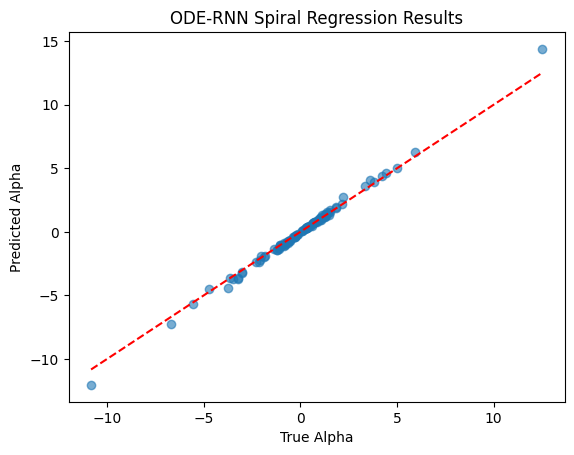

In [5]:
# 1. Load and Preprocess Data (75/25 Split)
data = np.load("/kaggle/input/spirals/spirals (1).npz")
all_obs = jnp.array(data['xy_train'])      # (10000, 100, 2)
all_alpha = jnp.array(data['alpha_train']) # (10000, 1)

num_samples = all_obs.shape[0]
indices = jrandom.permutation(jrandom.PRNGKey(42), num_samples)
train_idx, test_idx = indices[:7500], indices[7500:]

# Standard Scaling (Crucial for stability)
obs_mean, obs_std = jnp.mean(all_obs[train_idx]), jnp.std(all_obs[train_idx])
alpha_mean, alpha_std = jnp.mean(all_alpha[train_idx]), jnp.std(all_alpha[train_idx])

obs_norm = (all_obs - obs_mean) / (obs_std + 1e-6)
alpha_norm = (all_alpha - alpha_mean) / (alpha_std + 1e-6)

ts_common = jnp.linspace(0, 1, 100) # Assuming normalized time 0 to 1

# 2. Model Components
class VectorField(eqx.Module):
    net: eqx.nn.MLP
    projection: eqx.nn.Linear # Linear Projection to keep values small/stable

    def __init__(self, hidden_size, width_size, depth, key):
        k1, k2 = jrandom.split(key)
        self.projection = eqx.nn.Linear(hidden_size, hidden_size, key=k1)
        self.net = eqx.nn.MLP(
            in_size=hidden_size, out_size=hidden_size,
            width_size=width_size, depth=depth,
            activation=jax.nn.softplus, key=k2
        )

    def __call__(self, t, y, args):
        # Apply projection before MLP to ensure input isn't too large
        latent = self.projection(y)
        return self.net(latent)

class ODERNN(eqx.Module):
    vector_field: VectorField
    rnn_cell: eqx.nn.GRUCell
    linear_out: eqx.nn.Linear
    hidden_size: int

    def __init__(self, in_size, hidden_size, out_size, key):
        k1, k2, k3 = jrandom.split(key, 3)
        self.hidden_size = hidden_size
        self.vector_field = VectorField(hidden_size, hidden_size, 2, k1)
        self.rnn_cell = eqx.nn.GRUCell(in_size, hidden_size, key=k2)
        self.linear_out = eqx.nn.Linear(hidden_size, out_size, key=k3)

    def __call__(self, ts, obs):
        # obs: (100, 2)
        h0 = jnp.zeros(self.hidden_size)
        
        def scan_fn(carry, x):
            h_prev, t_prev = carry
            t_curr, obs_curr = x
            
            # Solve ODE between observations
            sol = diffrax.diffeqsolve(
                diffrax.ODETerm(self.vector_field),
                diffrax.Tsit5(),
                t0=t_prev,
                t1=t_curr,
                dt0=t_curr - t_prev,  # <--- PASS THE STEP SIZE HERE
                y0=h_prev,
                stepsize_controller=diffrax.ConstantStepSize()) 
            h_ode = sol.ys[-1] # Take last point of integration

            # Update state with new observation via GRU
            h_next = self.rnn_cell(obs_curr, h_ode)
            return (h_next, t_curr), None

        # Prepare scan: zip time and observations
        init_carry = (h0, ts[0])
        xs = (ts[1:], obs[1:])
        (h_final, _), _ = jax.lax.scan(scan_fn, init_carry, xs)

        return self.linear_out(h_final)

# 3. Training Setup
HIDDEN_SIZE = 64
model = ODERNN(in_size=2, hidden_size=HIDDEN_SIZE, out_size=1, key=jrandom.PRNGKey(0))
optimizer = optax.adamw(1e-3)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

@eqx.filter_value_and_grad
def loss_fn(model, batch_ts, batch_obs, batch_alpha):
    # Map the model over the batch
    pred_alphas = jax.vmap(model, in_axes=(None, 0))(batch_ts, batch_obs)
    return jnp.mean((pred_alphas - batch_alpha) ** 2)

@eqx.filter_jit
def make_step(model, opt_state, batch_ts, batch_obs, batch_y):
    loss, grads = loss_fn(model, batch_ts, batch_obs, batch_y)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

# 4. Training Loop
BATCH_SIZE = 128
EPOCHS = 20

for epoch in range(EPOCHS):
    indices = jrandom.permutation(jrandom.PRNGKey(epoch), len(train_idx))
    epoch_losses = []
    
    for i in range(0, len(train_idx), BATCH_SIZE):
        batch_idx = indices[i : i + BATCH_SIZE]
        b_obs = obs_norm[train_idx][batch_idx]
        b_alpha = alpha_norm[train_idx][batch_idx]
        
        model, opt_state, loss = make_step(model, opt_state, ts_common, b_obs, b_alpha)
        epoch_losses.append(loss)
    
    # Validation
    val_preds = jax.vmap(model, in_axes=(None, 0))(ts_common, obs_norm[test_idx][:500])
    val_loss = jnp.mean((val_preds - alpha_norm[test_idx][:500])**2)
    print(f"Epoch {epoch+1} | Train Loss: {jnp.mean(jnp.array(epoch_losses)):.6f} | Val Loss: {val_loss:.6f}")

# 5. Result Visualization
def predict_alpha(obs_batch):
    # Helper to denormalize predictions
    norm_obs = (obs_batch - obs_mean) / obs_std
    preds = jax.vmap(model, in_axes=(None, 0))(ts_common, norm_obs)
    return (preds * alpha_std) + alpha_mean

final_preds = predict_alpha(all_obs[test_idx][:100])
true_alphas = all_alpha[test_idx][:100]

plt.scatter(true_alphas, final_preds, alpha=0.6)
plt.plot([true_alphas.min(), true_alphas.max()], [true_alphas.min(), true_alphas.max()], 'r--')
plt.xlabel("True Alpha")
plt.ylabel("Predicted Alpha")
plt.title("ODE-RNN Spiral Regression Results")
plt.show()

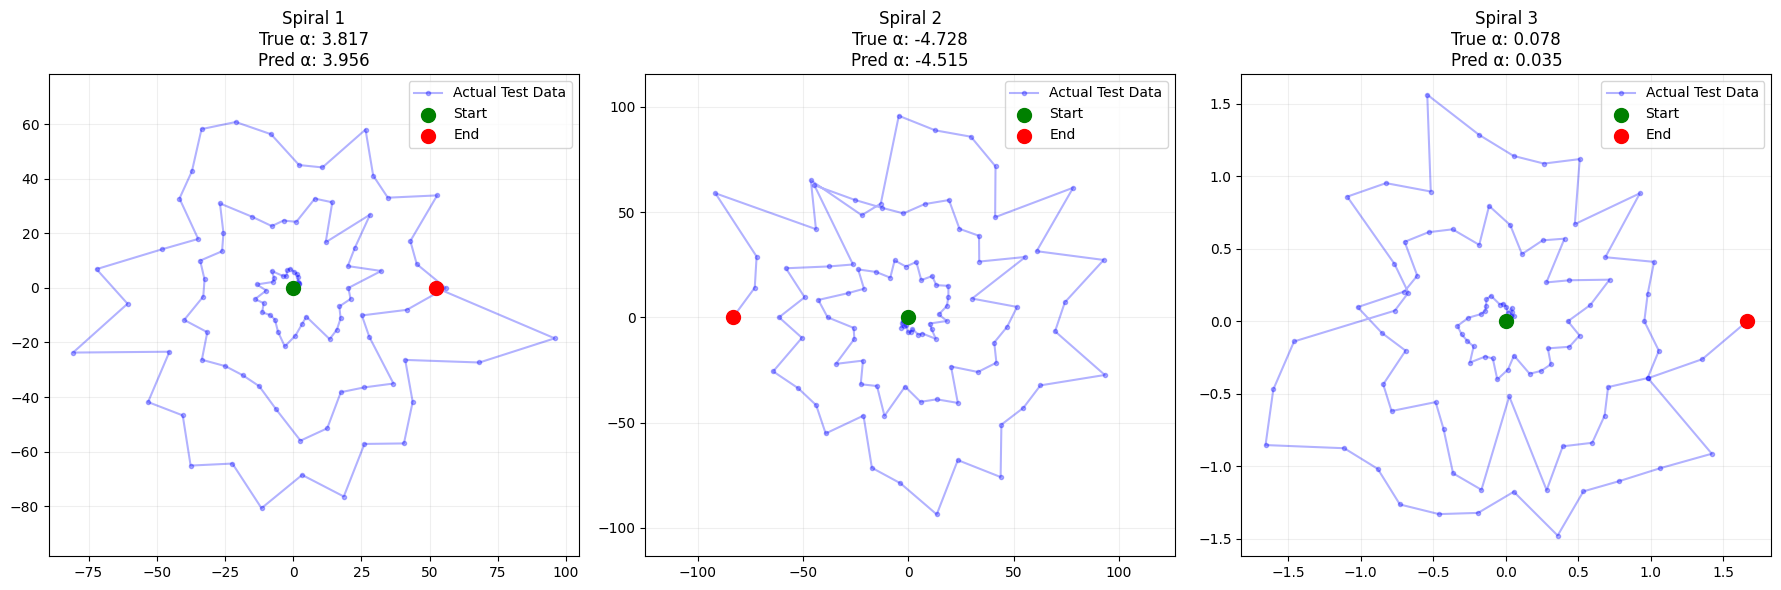

In [6]:
# 1. Pick 3 random spirals from the 25% test split
num_samples = 3
sample_indices = test_idx[:num_samples]

# Get the actual (X, Y) coordinates and the true Alpha
real_spirals = all_obs[sample_indices]  # Shape: (3, 100, 2)
true_alphas = all_alpha[sample_indices] # Shape: (3, 1)

# 2. Get the model's prediction for these 3 spirals
# (This uses the ODE-RNN logic you just ran)
pred_alphas = predict_alpha(real_spirals)

# 3. Plotting the actual "Test Spirals" from your dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i in range(num_samples):
    # The actual points from the dataset
    x_true = real_spirals[i, :, 0]
    y_true = real_spirals[i, :, 1]
    
    # Plot the true trajectory
    axes[i].plot(x_true, y_true, 'o-', color='blue', markersize=3, alpha=0.3, label='Actual Test Data')
    
    # Mark the start and end to see direction
    axes[i].scatter(x_true[0], y_true[0], color='green', s=100, label='Start', zorder=5)
    axes[i].scatter(x_true[-1], y_true[-1], color='red', s=100, label='End', zorder=5)
    
    # Title showing the "Truth" vs "Prediction"
    axes[i].set_title(f"Spiral {i+1}\nTrue α: {true_alphas[i,0]:.3f}\nPred α: {pred_alphas[i,0]:.3f}")
    axes[i].axis('equal')
    axes[i].grid(True, alpha=0.2)
    axes[i].legend()

plt.tight_layout()
plt.show()

## Model 2: Latent Neural SDE

The Latent SDE models the spiral as a **stochastic latent process**, explicitly capturing uncertainty.

**Model Parameters**
- Latent size: $8$  
- Encoder hidden size: $128$  
- Decoder hidden size: $128$  
- Number of sampled paths per input: $K = 5$  

**Architecture**
- **Encoder:** GRUCell$(2 \rightarrow 128)$ followed by Linear$(128 \rightarrow 8)$  
- **Drift Network:**  
  - Input: latent state + time features $(8 + 3)$  
  - Linear projection to latent size  
  - MLP depth: $3$  
  - Width: $128$  
  - Activation: Softplus  
- **Diffusion Network:**  
  - Linear projection in latent space  
  - MLP depth: $2$  
  - Width: $128$  
  - Output reshaped to $(8 \times 8)$ diffusion matrix  
- **Decoder:** MLP$(8 \rightarrow 2)$  
  - Depth: $2$  
  - Activation: Tanh  

**Dynamics**
- SDE:  
  $$dz_t = f_\theta(z_t, t)\,dt + g_\phi(z_t, t)\,dW_t$$
- Brownian motion: VirtualBrownianTree  
- Solver: **Heun**  
- Step size: constant, $dt = 0.01$  

**Fourier Time Features**
Time is *encoded* as:
$$[t,\; \sin(2\pi t),\; \cos(2\pi t)]$$  
This explicitly enforces rotational periodicity and removes trajectory “hooking”.

**Training Setup**
- Optimizer: AdamW with global norm clipping  
- Learning rate: $10^{-3}$  
- Steps: $2000$  
- Batch size: $64$  
- Loss: Huber loss  
- Gradient clipping: elementwise clamp to $[-0.01, 0.01]$  

**Stability Measures**
- Standard scaling of inputs  
- Linear projection layers before MLPs  
- Small diffusion scaling ($\times 0.01$)  

**Key Property**
- Produces a distribution of trajectories rather than a single path.


  0%|          | 0/2000 [00:00<?, ?it/s]

Step 0 | Train Loss: 0.03554 | Test Loss: 0.03990
Step 400 | Train Loss: 0.02414 | Test Loss: 0.02416
Step 800 | Train Loss: 0.01225 | Test Loss: 0.01730
Step 1200 | Train Loss: 0.01044 | Test Loss: 0.01526
Step 1600 | Train Loss: 0.00643 | Test Loss: 0.00621


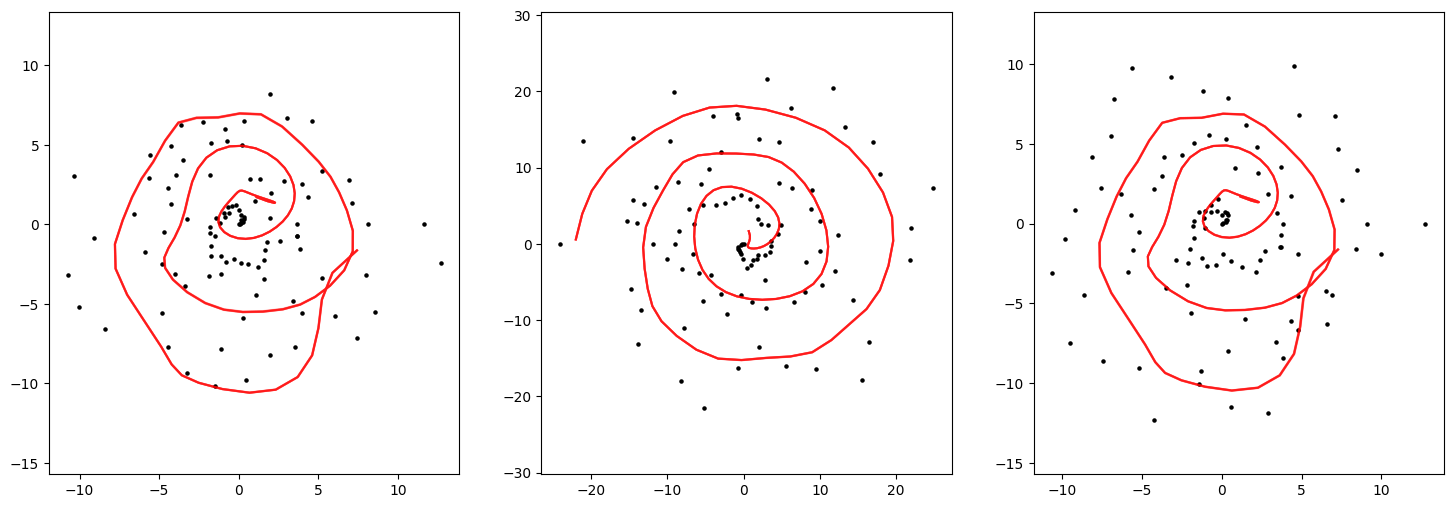

In [17]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
import equinox as eqx
import optax
import diffrax as dfx
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np

# 1. Data & Scaling (75/25 Split)
data = np.load("/kaggle/input/spirals/spirals (1).npz")
all_xy = jnp.array(data['xy_train']) 

train_xy = all_xy[:7500]
test_xy = all_xy[7500:]

# Standard Scaling based on train set only
xy_mean, xy_std = jnp.mean(train_xy), jnp.std(train_xy)
train_norm = (train_xy - xy_mean) / (xy_std + 1e-6)
test_norm = (test_xy - xy_mean) / (xy_std + 1e-6)
ts_norm = jnp.linspace(0, 1, 100)

# 2. Config
LATENT_SIZE = 8
HIDDEN_SIZE = 128 # Increased for better capacity
K_SAMPLES = 5
LEARNING_RATE = 1e-3
STEPS = 2000

# 3. Time Encoding (The secret to killing the "hook")
def get_time_features(t):
    # Map t to a 3D vector: [t, sin(2pi*t), cos(2pi*t)]
    # This forces the model to acknowledge rotational periods.
    return jnp.array([t, jnp.sin(2 * jnp.pi * t), jnp.cos(2 * jnp.pi * t)])

class LatentDrift(eqx.Module):
    projection: eqx.nn.Linear
    mlp: eqx.nn.MLP
    def __init__(self, latent_size, hidden_size, key):
        k1, k2 = jrandom.split(key)
        # Input is [z (8) + time_features (3)] = 11
        self.projection = eqx.nn.Linear(latent_size + 3, latent_size, key=k1)
        self.mlp = eqx.nn.MLP(latent_size, latent_size, hidden_size, 3, jax.nn.softplus, key=k2)
        
    def __call__(self, t, z, args):
        t_feat = get_time_features(t)
        zt = jnp.concatenate([z, t_feat])
        # Linear Projection ensures MLP isn't fed raw/large values
        return self.mlp(self.projection(zt))

class LatentDiffusion(eqx.Module):
    projection: eqx.nn.Linear
    mlp: eqx.nn.MLP
    def __init__(self, latent_size, hidden_size, key):
        k1, k2 = jrandom.split(key)
        self.projection = eqx.nn.Linear(latent_size, latent_size, key=k1)
        self.mlp = eqx.nn.MLP(latent_size, latent_size**2, hidden_size, 2, jax.nn.softplus, key=k2)
        
    def __call__(self, t, z, args):
        flat_matrix = self.mlp(self.projection(z)) * 0.01 + 1e-4
        return flat_matrix.reshape(LATENT_SIZE, LATENT_SIZE)

class LatentSDE(eqx.Module):
    encoder: eqx.nn.GRUCell
    enc_proj: eqx.nn.Linear
    drift: LatentDrift
    diffusion: LatentDiffusion
    decoder: eqx.nn.MLP # Upgraded to MLP for better coordinate mapping
    
    def __init__(self, key):
        k1, k2, k3, k4, k5 = jrandom.split(key, 5)
        self.encoder = eqx.nn.GRUCell(2, HIDDEN_SIZE, key=k1)
        self.enc_proj = eqx.nn.Linear(HIDDEN_SIZE, LATENT_SIZE, key=k2)
        self.drift = LatentDrift(LATENT_SIZE, HIDDEN_SIZE, k3)
        self.diffusion = LatentDiffusion(LATENT_SIZE, HIDDEN_SIZE, k4)
        self.decoder = eqx.nn.MLP(LATENT_SIZE, 2, HIDDEN_SIZE, 2, jax.nn.tanh, key=k5)

    def encode(self, obs):
        h = jnp.zeros(HIDDEN_SIZE)
        for y in obs: h = self.encoder(y, h)
        return self.enc_proj(h)

# 4. Solver and Huber Loss
def solve_sde(model, z0, ts, key):
    bm = dfx.VirtualBrownianTree(t0=ts[0], t1=ts[-1], tol=1e-3, shape=(LATENT_SIZE,), key=key)
    terms = dfx.MultiTerm(dfx.ODETerm(model.drift), dfx.ControlTerm(model.diffusion, bm))
    sol = dfx.diffeqsolve(terms, dfx.Heun(), t0=ts[0], t1=ts[-1], dt0=0.01, y0=z0,
                          saveat=dfx.SaveAt(ts=ts), stepsize_controller=dfx.ConstantStepSize())
    return jax.vmap(model.decoder)(sol.ys)

@eqx.filter_value_and_grad
def loss_fn(model, batch_xy, key):
    z0_batch = jax.vmap(model.encode)(batch_xy)
    def single_loss(z0, true_xy, k_key):
        keys = jrandom.split(k_key, K_SAMPLES)
        preds = jax.vmap(lambda k: solve_sde(model, z0, ts_norm, k))(keys)
        # Huber loss prevents one "bad" path from ruining the whole training run
        diff = preds - true_xy
        return jnp.mean(jnp.where(jnp.abs(diff) < 0.1, 0.5 * diff**2, 0.1 * (jnp.abs(diff) - 0.05)))
    
    return jnp.mean(jax.vmap(single_loss)(z0_batch, batch_xy, jrandom.split(key, batch_xy.shape[0])))

@eqx.filter_jit
def step(model, opt_state, batch_xy, key):
    loss, grads = loss_fn(model, batch_xy, key)
    # Clamp gradients to keep the Tanh layers from saturating
    grads = jax.tree_util.tree_map(lambda g: jnp.clip(g, -0.01, 0.01), grads)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    return eqx.apply_updates(model, updates), opt_state, loss

# 5. Initialization & Training
optimizer = optax.chain(optax.clip_by_global_norm(1.0), optax.adamw(LEARNING_RATE))
model = LatentSDE(jrandom.PRNGKey(42))
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

for i in tqdm(range(STEPS)):
    key = jrandom.PRNGKey(i)
    idx = jrandom.randint(key, (64,), 0, len(train_norm))
    model, opt_state, train_loss = step(model, opt_state, train_norm[idx], key)
    
    if i % 400 == 0:
        t_key = jrandom.PRNGKey(i+1)
        t_idx = jrandom.randint(t_key, (100,), 0, len(test_norm))
        t_loss, _ = loss_fn(model, test_norm[t_idx], t_key)
        print(f"Step {i} | Train Loss: {train_loss:.5f} | Test Loss: {t_loss:.5f}")

# 6. Final Visualization (Test Set 2500)
def plot_final(model):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for i in range(3):
        # Using the test split (the 2500 you requested)
        z0 = model.encode(test_norm[i])
        keys = jrandom.split(jrandom.PRNGKey(i), 20)
        preds = (jax.vmap(lambda k: solve_sde(model, z0, ts_norm, k))(keys) * xy_std) + xy_mean
        
        for j in range(20):
            axes[i].plot(preds[j,:,0], preds[j,:,1], color='red', alpha=0.1)
        axes[i].scatter(test_xy[i,:,0], test_xy[i,:,1], color='black', s=5, label='Actual Test Data')
        axes[i].axis('equal')
    plt.show()

plot_final(model)

## Final Interpretation

- The **ODE-RNN** is well-suited for clean, deterministic systems and accurately captures the average spiral shape.  
- The **Latent SDE** models both the spiral structure and its inherent variability.  
- Injecting **Fourier time features** provides a strong inductive bias for periodic motion and is critical for good SDE performance.  
- On this dataset, allowing stochasticity leads to a more flexible model and slightly better predictive accuracy.
